# 🚦 LLM Model Router

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/llm-router/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/llm-router/demo.ipynb)

**Stop paying frontier-model prices for "what's the capital of France?"**

Most production traffic is easy and a small model handles it fine; only a minority needs the frontier model. This notebook builds a transparent, rule-based router that scores each request's complexity and sends it to the **smallest capable tier** - then measures the cost saved versus always-large.

**What we cover**
1. Model tiers + prices
2. Scoring complexity from cheap signals
3. Routing to the smallest capable tier
4. Route a mixed traffic stream
5. Cost + distribution chart
6. Try your own request

## 1. Model tiers

Three tiers with illustrative per-1M-token prices (Haiku / Sonnet / Opus-class). Each tier has a complexity ceiling; a request routes to the first tier it fits under.

In [1]:
from __future__ import annotations
import re
from dataclasses import dataclass
from typing import List, Tuple

@dataclass
class Tier:
    name: str; price_per_mtok: float; max_score: float

TIERS = [
    Tier("small", 0.30, 0.34),
    Tier("medium", 3.00, 0.67),
    Tier("large", 15.00, 1.01),
]
for t in TIERS:
    print(f"{t.name:<7} ${t.price_per_mtok:>6.2f}/Mtok   route if complexity <= {t.max_score}")

small   $  0.30/Mtok   route if complexity <= 0.34
medium  $  3.00/Mtok   route if complexity <= 0.67
large   $ 15.00/Mtok   route if complexity <= 1.01


## 2. Score complexity

Cheap, transparent signals. Length, reasoning/analysis cues, code, structured output, multiple questions push the score **up**; explicit simple-task cues push it **down**. Cue patterns match word *stems* so "explain" also catches "explaining".

In [2]:
_REASON = re.compile(r"\b(?:why|explain|analy[sz]|reason|prove|deriv|strateg|trade[- ]?off|compar|evaluat|debug|design|architect|recommend|refactor|optimi[sz]|step[- ]by[- ]step|root cause)\w*", re.I)
_CODE = re.compile(r"\b(?:code|function|regex|sql|python|javascript|algorithm|stack trace|unit test|typescript|api)\b|```", re.I)
_STRUCT = re.compile(r"\b(?:json|schema|table|csv|markdown|yaml|xml)\b", re.I)
_SIMPLE = re.compile(r"\b(?:classif|categori[sz]|label|extract|sentiment|yes/no|translat|tag|detect|spellcheck)\w*", re.I)

def complexity_score(text):
    reasons=[]; score=0.0
    w=len(text.split())
    if w>120: score+=0.35; reasons.append(f"long input ({w} words)")
    elif w>40: score+=0.18; reasons.append(f"medium input ({w} words)")
    nr=len(_REASON.findall(text))
    if nr: score+=min(0.40, 0.20*nr); reasons.append(f"reasoning cues x{nr}")
    if _CODE.search(text): score+=0.30; reasons.append("code/technical")
    if _STRUCT.search(text): score+=0.10; reasons.append("structured output")
    nq=text.count("?")
    if nq>=2: score+=0.12; reasons.append(f"multiple questions ({nq})")
    if _SIMPLE.search(text) and w<=40 and not _CODE.search(text):
        score-=0.20; reasons.append("simple task cue")
    score=round(max(0.0,min(1.0,score)),3)
    if not reasons: reasons.append("short, generic")
    return score, reasons

for t in ["What is the capital of France?",
          "Explain step-by-step why this SQL query returns duplicate rows."]:
    print(complexity_score(t), "<-", t[:45])

(0.0, ['short, generic']) <- What is the capital of France?
(0.7, ['reasoning cues x3', 'code/technical']) <- Explain step-by-step why this SQL query retur


## 3. Route to the smallest capable tier

In [3]:
def route(text, est_tokens=800):
    score, reasons = complexity_score(text)
    chosen = TIERS[-1]
    for t in TIERS:
        if score <= t.max_score:
            chosen = t; break
    return {"request": text, "score": score, "tier": chosen.name,
            "reasons": reasons, "est_tokens": est_tokens}

def price(name): return next(t.price_per_mtok for t in TIERS if t.name==name)
def cost_of(r, name): return r["est_tokens"]/1_000_000*price(name)

r = route("Design a retry-with-backoff strategy and explain the trade-offs.")
print(r["tier"], r["score"], r["reasons"])

medium 0.4 ['reasoning cues x4']


## 4. Route a mixed traffic stream

A realistic mix skewed toward easy requests, with a few genuinely hard ones.

In [4]:
TRAFFIC = [
    ("Classify this review sentiment as positive, negative, or neutral: 'Love it!'", 300),
    ("Extract the invoice number and total from this line.", 250),
    ("Translate 'good morning' to Spanish.", 120),
    ("Tag this ticket with one of: billing, login, shipping.", 200),
    ("Summarize this paragraph in one sentence.", 400),
    ("What is the capital of France?", 80),
    ("Return the order status as JSON with fields id and state.", 260),
    ("Explain step-by-step why this SQL query returns duplicate rows and how to fix it.", 1400),
    ("Design a retry-with-backoff strategy for our ingestion pipeline and explain the trade-offs versus a dead-letter queue.", 1600),
    ("Debug this Python stack trace and propose a fix with a unit test.", 1500),
    ("Compare three architectures for a real-time feature store and recommend one, explaining the reasoning and cost trade-offs for our scale.", 1800),
    ("Refactor this function for readability and analyze the time complexity.", 1200),
    ("Is this email spam? Answer yes or no.", 150),
    ("Categorize this support message into a product area.", 220),
    ("Write and explain a regex that validates E.164 phone numbers, with edge cases.", 1300),
]

import pandas as pd
rows=[]; routed=0.0; large=0.0; counts={t.name:0 for t in TIERS}
for text, toks in TRAFFIC:
    r=route(text, toks); rc=cost_of(r,r["tier"]); lc=cost_of(r,"large")
    routed+=rc; large+=lc; counts[r["tier"]]+=1
    rows.append({"request": text[:55]+"...", "score": r["score"], "tier": r["tier"], "cost": round(rc,6)})
df=pd.DataFrame(rows)
saved=large-routed; pct=round(100*saved/large,1)
print(f"distribution: {counts}")
print(f"always-large ${large:.4f}  |  routed ${routed:.4f}  |  saved ${saved:.4f} ({pct}%)")
df

distribution: {'small': 9, 'medium': 4, 'large': 2}
always-large $0.1617  |  routed $0.0582  |  saved $0.1035 (64.0%)


,request,score,tier,cost
0,"Classify this review sentiment as positive, ne...",0.0,small,0.000090
1,Extract the invoice number and total from this...,0.0,small,0.000075
2,Translate 'good morning' to Spanish....,0.0,small,0.000036
3,"Tag this ticket with one of: billing, login, s...",0.0,small,0.000060
4,Summarize this paragraph in one sentence....,0.0,small,0.000120
5,What is the capital of France?...,0.0,small,0.000024
6,Return the order status as JSON with fields id...,0.1,small,0.000078
7,Explain step-by-step why this SQL query return...,0.7,large,0.021000
8,Design a retry-with-backoff strategy for our i...,0.4,medium,0.004800
9,Debug this Python stack trace and propose a fi...,0.5,medium,0.004500


## 5. Cost + distribution chart

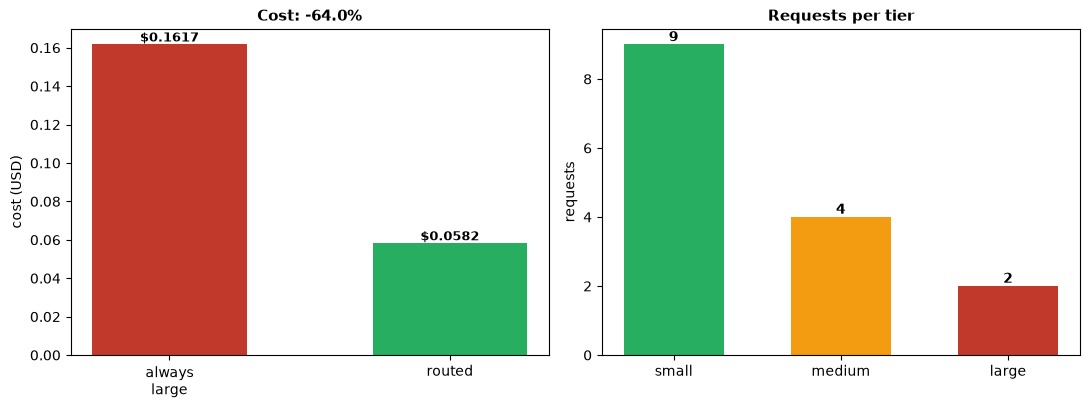

In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# Left: cost comparison
bars = ax1.bar(["always\nlarge", "routed"], [large, routed], color=["#c0392b", "#27ae60"], width=0.55)
ax1.set_ylabel("cost (USD)"); ax1.set_title(f"Cost: -{pct}%", fontsize=11, weight="bold")
for b, v in zip(bars, [large, routed]):
    ax1.text(b.get_x()+b.get_width()/2, v, f"${v:.4f}", ha="center", va="bottom", fontsize=9, weight="bold")

# Right: tier distribution
order = ["small","medium","large"]
ax2.bar(order, [counts[t] for t in order], color=["#27ae60","#f39c12","#c0392b"], width=0.6)
ax2.set_ylabel("requests"); ax2.set_title("Requests per tier", fontsize=11, weight="bold")
for i, t in enumerate(order):
    ax2.text(i, counts[t], str(counts[t]), ha="center", va="bottom", fontsize=10, weight="bold")

plt.tight_layout()
plt.savefig("routing_cost.png", dpi=130, bbox_inches="tight")
plt.show()

Two-thirds of the bill disappears by sending the 9 easy requests to a cheap tier - while the 2 genuinely hard ones still get the frontier model. The scoring is fully transparent, so you can see *why* each request landed where it did and tune the thresholds to your quality bar.

## Try your own request

In [6]:
my_request = "Summarize this earnings call and list three risks with reasoning."
r = route(my_request)
print("tier:  ", r["tier"], f"(${price(r['tier']):.2f}/Mtok)")
print("score: ", r["score"])
print("why:   ", "; ".join(r["reasons"]))

tier:   small ($0.30/Mtok)
score:  0.2
why:    reasoning cues x1


---

**Part of [Phoebe's FDE build sprint](https://github.com/phoebefu6/phoebe-the-builder)** - Day 90, LLMOps & GenAI Platform.

Streamlit version (route a stream + test any request):
```bash
pip install -r requirements.txt
streamlit run app.py
```